# The Prior Is the Portfolio — a quantitative teardown \U0001F52C
### The zero-view identity · view-strength calibration · prior versus view · an out-of-sample race

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). One design
choice shapes the whole study: **no market-capitalisation data is used**. The textbook prior is
the cap-weighted market, a price feed does not carry caps, and inventing them would be worse
than running three explicit priors and reporting how far apart their answers land.

> ⚠️ **Not investment advice.** Total-return closes from Yahoo! Finance pinned as-of the date
> in [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from bl_prior import data, strategy as st

px = data.load_prices()
rets = px.pct_change()
panels = {"multi-asset": [c for c in data.MULTI if rets[c].notna().sum() > 3000],
          "sectors": [c for c in data.SECTORS if rets[c].notna().sum() > 1500]}
cols = panels["multi-asset"]
sub = rets[cols].dropna(how="any")
cov = np.cov(sub.iloc[-504:].to_numpy(), rowvar=False, ddof=1)
print(f"as-of {data.AS_OF} | {len(cols)} sleeves | tau={st.DEFAULT_TAU} delta={st.DEFAULT_DELTA}")
print(", ".join(cols))

as-of 2026-06-30 | 10 sleeves | tau=0.05 delta=2.5
SPY, IWM, EFA, EEM, TLT, IEF, LQD, HYG, GLD, DBC


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Weak | The zero-view identity is exact: with no views the posterior portfolio equals the prior to **3.2e-11** of the book, for every prior, every tau and every covariance tested. So the model contributes no information of its own — it is a blending rule. What it *does* contribute is a calibrated way to size a tilt: a 3%/yr view on one sleeve moves **4.3%** of the book at tau = 0.05, rising to 18.0% for a 10%/yr view. And the choice of prior matters more than the view: the same view under three defensible priors produces portfolios **19.3%** apart, against the 2.4% the view itself moved. |
| **Tradability** | Mirage | With a mechanical 12-1 momentum view sized at 3%/yr, the tilted portfolio returned **+7.24%/yr** at 8.82% volatility (Sharpe +0.82) against **+8.26%** / +0.94 for the untouched prior — paired *t* on the return difference **-1.15** across 68 rebalances. Plain mean-variance on the same data managed +7.28% / +1.09 with a largest weight of 52% against the tilted book's 18%, which is the comparison Black-Litterman was invented to win — and does. |

> \U0001F4A1 **In plain words.** The model is a disciplined way to hold a prior and tilt it. It
> is a very good one. It is not a source of information.

## 1 · The algebra

Reverse optimisation: ``pi = delta * Sigma * w_prior``.

Posterior mean:

    mu_bl = [(tau Sigma)^-1 + P' Omega^-1 P]^-1 [(tau Sigma)^-1 pi + P' Omega^-1 q]

Portfolio: ``w = (1/delta) Sigma^-1 mu_bl``, normalised.

- **H₁.** With ``P`` empty, ``mu_bl = pi`` and ``w = w_prior`` exactly, for every ``tau``,
  ``delta`` and ``Sigma`` — including singular ones.
- **H₂.** ``delta`` cancels out of the portfolio entirely (it scales ``pi`` and un-scales the
  optimisation).
- **H₃.** The book moved by a view is increasing in the view's size and in ``tau``.
- **H₄.** The spread between priors exceeds the movement caused by a plausibly sized view.

## 2 · H₁ and H₂, pinned

In [3]:
rows = []
for kind in st.PRIORS:
    wp = st.prior_weights(cov, kind)
    for tau in (0.001, 0.01, 0.05, 0.25, 1.0, 10.0):
        for delta in (1.0, 2.5, 10.0):
            wb = st.posterior_weights(cov, wp, tau=tau, delta=delta)
            rows.append({"prior": kind, "tau": tau, "delta": delta,
                         "error": np.abs(wb - wp).sum() / 2})
d = pd.DataFrame(rows)
print(f"worst error across {len(d)} combinations: {d['error'].max():.3e}")
thin = np.cov(sub.iloc[-30:].to_numpy(), rowvar=False, ddof=1)
wp_thin = st.prior_weights(thin, "inverse_vol")
print(f"on a singular covariance (30 rows, {len(cols)} assets): "
      f"{np.abs(st.posterior_weights(thin, wp_thin) - wp_thin).sum() / 2:.3e}")
print(f"eigenvalues of that matrix span "
      f"{np.linalg.eigvalsh(thin).min():.2e} to {np.linalg.eigvalsh(thin).max():.2e}")

worst error across 54 combinations: 1.358e-11
on a singular covariance (30 rows, 10 assets): 3.151e-11
eigenvalues of that matrix span 2.64e-07 to 9.86e-04


## 3 · The teardown

### 3.1 What "equilibrium returns" are

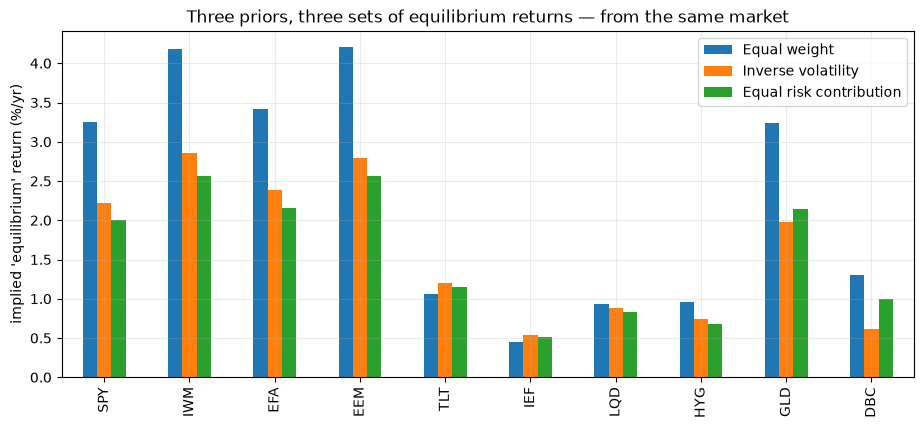

     Equal weight  Inverse volatility  Equal risk contribution
SPY        0.0325              0.0222                   0.0200
IWM        0.0418              0.0286                   0.0256
EFA        0.0341              0.0238                   0.0216
EEM        0.0420              0.0279                   0.0257
TLT        0.0106              0.0120                   0.0115
IEF        0.0045              0.0053                   0.0051
LQD        0.0093              0.0088                   0.0083
HYG        0.0096              0.0074                   0.0067
GLD        0.0324              0.0198                   0.0214
DBC        0.0130              0.0061                   0.0100

No return data was used to produce any of these numbers.


In [4]:
rows = {}
for kind in st.PRIORS:
    wp = st.prior_weights(cov, kind)
    rows[st.PRIOR_LABEL[kind]] = st.implied_returns(cov, wp) * 252
d = pd.DataFrame(rows, index=cols)
fig, ax = plt.subplots(figsize=(11, 4.5))
(d * 100).plot.bar(ax=ax)
ax.set_ylabel("implied 'equilibrium' return (%/yr)"); ax.legend(title="")
ax.set_title("Three priors, three sets of equilibrium returns — from the same market")
plt.show()
print(d.round(4).to_string())
print("\nNo return data was used to produce any of these numbers.")

> \U0001F4A1 **In plain words.** The phrase "equilibrium returns" suggests a market observation.
> It is the prior portfolio multiplied by the covariance matrix. Change the prior and the
> equilibrium changes with it.

### 3.2 The view-strength surface

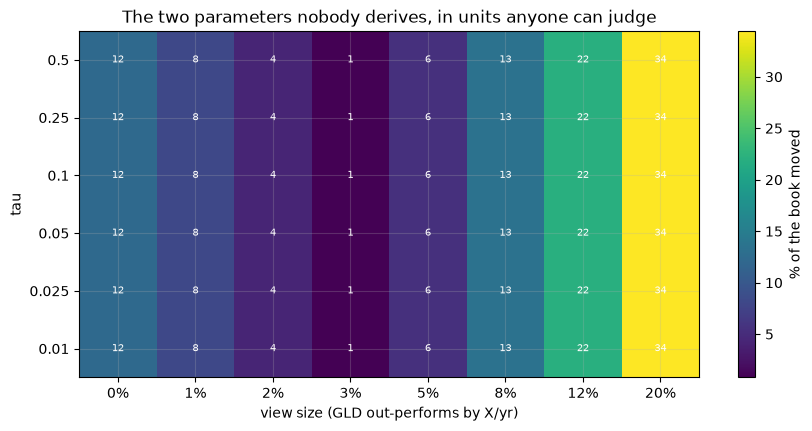

In [5]:
wp = st.prior_weights(cov, "equal")
asset = cols.index("GLD") if "GLD" in cols else 0
sizes = np.array([0.0, 0.01, 0.02, 0.03, 0.05, 0.08, 0.12, 0.20])
taus = np.array([0.01, 0.025, 0.05, 0.10, 0.25, 0.5])
Z = np.zeros((len(taus), len(sizes)))
for i, tau in enumerate(taus):
    for j, s in enumerate(sizes):
        P, q = st.single_view(len(cols), asset, s)
        w = st.posterior_weights(cov, wp, P, q, tau=tau)
        Z[i, j] = np.abs(w - wp).sum() / 2
fig, ax = plt.subplots(figsize=(10, 4.5))
im = ax.imshow(Z * 100, aspect="auto", cmap="viridis", origin="lower")
ax.set_xticks(range(len(sizes))); ax.set_xticklabels([f"{s:.0%}" for s in sizes])
ax.set_yticks(range(len(taus))); ax.set_yticklabels([f"{t:.3g}" for t in taus])
ax.set_xlabel(f"view size ({cols[asset]} out-performs by X/yr)"); ax.set_ylabel("tau")
for i in range(len(taus)):
    for j in range(len(sizes)):
        ax.text(j, i, f"{Z[i, j] * 100:.0f}", ha="center", va="center", color="w", fontsize=7)
fig.colorbar(im, ax=ax, label="% of the book moved")
ax.set_title("The two parameters nobody derives, in units anyone can judge")
plt.show()

### 3.3 Prior versus view

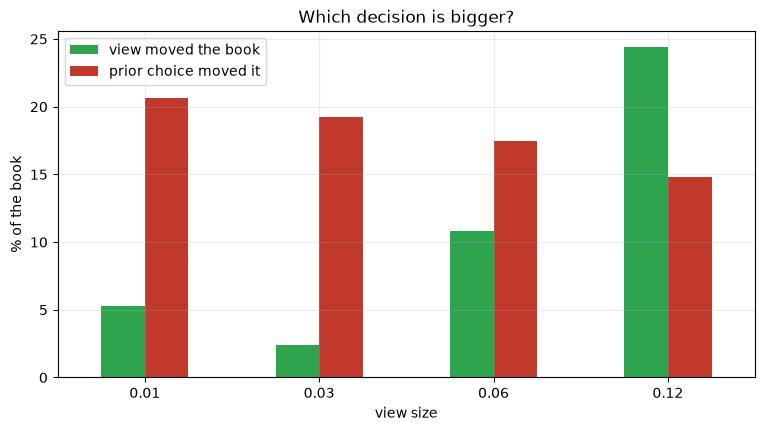

,view moved the book,prior choice moved it
view size,,
0.0100,0.0529,0.2065
0.0300,0.0239,0.1926
0.0600,0.1084,0.1749
0.1200,0.2437,0.1478


In [6]:
rows = []
for size in (0.01, 0.03, 0.06, 0.12):
    sens = st.prior_sensitivity(cov, asset=asset, size_ann=size)
    pw = sens.filter(like="vs_").to_numpy()
    rows.append({"view size": size, "view moved the book": sens["view_moved_book"].mean(),
                 "prior choice moved it": np.nanmean(pw)})
d = pd.DataFrame(rows).set_index("view size")
fig, ax = plt.subplots(figsize=(9, 4.5))
(d * 100).plot.bar(ax=ax, color=["#2ea44f", "#c0392b"])
ax.set_ylabel("% of the book"); ax.legend(title="")
ax.set_title("Which decision is bigger?")
plt.setp(ax.get_xticklabels(), rotation=0)
plt.show()
d.round(4)

### 3.4 Out of sample, all priors, both panels

      panel                   prior  prior Sharpe  BL Sharpe  plain MV Sharpe  t (BL - prior)   tilt
multi-asset            Equal weight        0.9390     0.8200           1.0900         -1.1530 0.2440
multi-asset      Inverse volatility        1.0150     0.8480           1.0900         -0.5030 0.2170
multi-asset Equal risk contribution        0.8940     0.8080           1.0900         -1.2690 0.2790
    sectors            Equal weight        1.1070     1.0960           0.9490         -0.1210 0.2370
    sectors      Inverse volatility        1.0610     1.0690           0.9490          0.1890 0.2330
    sectors Equal risk contribution        1.0660     1.0770           0.9490          0.2390 0.2320


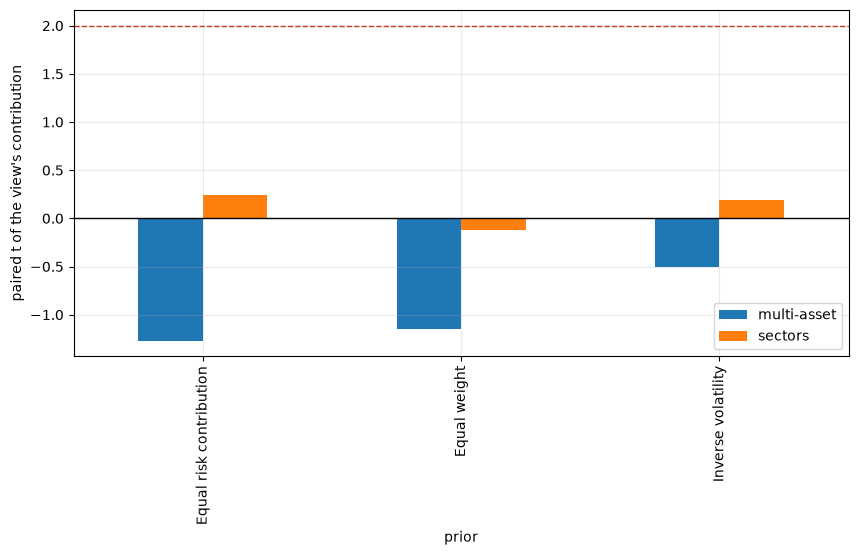

In [7]:
all_wf = {}
for tag, cs in panels.items():
    s_sub = rets[cs].dropna(how="any")
    for kind in st.PRIORS:
        wf = st.walk_forward(s_sub, prior_kind=kind, window=504, step=63, size_ann=0.03,
                             cost_bps=5.0)
        all_wf[(tag, kind)] = wf
rows = []
for (tag, kind), wf in all_wf.items():
    s = st.summarise(wf)
    p = st.paired_test(wf, "black_litterman", "prior")
    rows.append({"panel": tag, "prior": st.PRIOR_LABEL[kind],
                 "prior Sharpe": s.loc["prior", "sharpe"],
                 "BL Sharpe": s.loc["black_litterman", "sharpe"],
                 "plain MV Sharpe": s.loc["plain_mv", "sharpe"],
                 "t (BL - prior)": p["t"], "tilt": s.loc["black_litterman", "tilt_from_prior"]})
d = pd.DataFrame(rows)
print(d.round(3).to_string(index=False))
fig, ax = plt.subplots(figsize=(10, 4.5))
d.pivot(index="prior", columns="panel", values="t (BL - prior)").plot.bar(ax=ax)
ax.axhline(0, color="k", lw=1); ax.axhline(2, ls="--", color="#c0392b", lw=1)
ax.set_ylabel("paired t of the view's contribution"); ax.legend(title="")
plt.show()

### 3.5 The view-size sweep

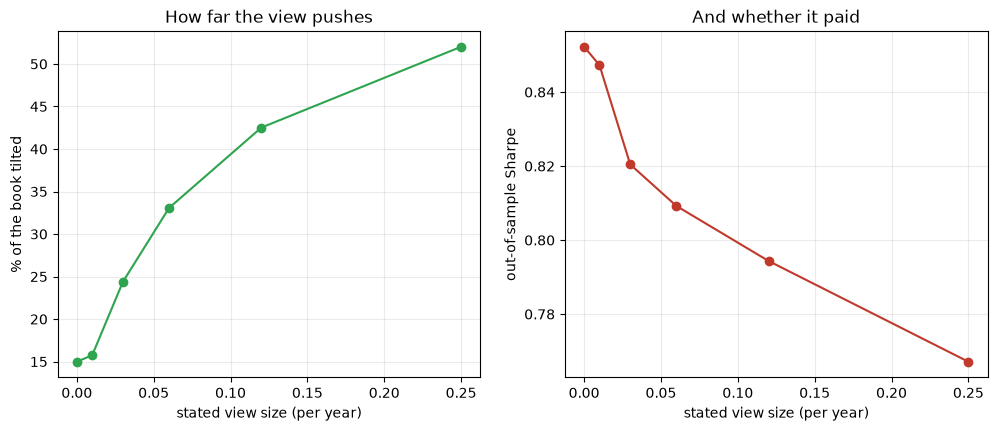

,tilt,Sharpe,turnover,t vs prior
view,,,,
0.0000,0.1498,0.8522,0.2993,-3.1705
0.0100,0.1575,0.8473,0.3298,-2.2943
0.0300,0.2439,0.8204,0.4400,-1.1530
0.0600,0.3307,0.8092,0.5071,-0.5378
0.1200,0.4251,0.7944,0.5652,-0.0679
0.2500,0.5202,0.7671,0.6168,0.1352


In [8]:
rows = []
s_sub = rets[panels["multi-asset"]].dropna(how="any")
for size in (0.0, 0.01, 0.03, 0.06, 0.12, 0.25):
    wf = st.walk_forward(s_sub, "equal", window=504, step=63, size_ann=size, cost_bps=5.0)
    s = st.summarise(wf)
    p = st.paired_test(wf, "black_litterman", "prior")
    rows.append({"view": size, "tilt": s.loc["black_litterman", "tilt_from_prior"],
                 "Sharpe": s.loc["black_litterman", "sharpe"],
                 "turnover": s.loc["black_litterman", "turnover"],
                 "t vs prior": p["t"]})
d = pd.DataFrame(rows).set_index("view")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
(d["tilt"] * 100).plot(ax=axes[0], marker="o", color="#2ea44f")
axes[0].set_ylabel("% of the book tilted"); axes[0].set_title("How far the view pushes")
d["Sharpe"].plot(ax=axes[1], marker="o", color="#c0392b")
axes[1].set_ylabel("out-of-sample Sharpe"); axes[1].set_title("And whether it paid")
for a in axes:
    a.set_xlabel("stated view size (per year)")
plt.show()
d.round(4)

> \U0001F4A1 **In plain words.** The zero-view row is the control: the tilt is zero and the
> performance is the prior's, exactly as the identity requires. Everything above it is the
> view's contribution, and the sweep shows how quickly it stops being free.

## 4 · The verdict

In [9]:
wf = all_wf[("multi-asset", "equal")]
s = st.summarise(wf)
pd.DataFrame({
    "zero-view identity error": [f"{np.abs(st.posterior_weights(cov, st.prior_weights(cov, 'equal')) - st.prior_weights(cov, 'equal')).sum() / 2:.2e}"],
    "book moved by a 3%/yr view": [f"{st.prior_sensitivity(cov, asset, 0.03)['view_moved_book'].mean():.1%}"],
    "BL Sharpe": [f"{s.loc['black_litterman', 'sharpe']:+.2f}"],
    "prior Sharpe": [f"{s.loc['prior', 'sharpe']:+.2f}"],
    "plain MV Sharpe": [f"{s.loc['plain_mv', 'sharpe']:+.2f}"],
    "t (BL - prior)": [f"{st.paired_test(wf, 'black_litterman', 'prior')['t']:+.2f}"],
}).T.rename(columns={0: "value"})

,value
zero-view identity error,5.11e-12
book moved by a 3%/yr view,2.4%
BL Sharpe,+0.82
prior Sharpe,+0.94
plain MV Sharpe,+1.09
t (BL - prior),-1.15


## 5 · Going further

- **Idzorek's confidence specification** replaces Omega with a percentage confidence, which is
  a far better human interface to the same algebra.
- **Omega from a track record**: if a view generator has a measurable hit rate, its uncertainty
  is estimable rather than assumed. Almost nobody does this, and it is the most obvious
  improvement available.
- **Cap-weighted prior**: with market-capitalisation data the textbook version becomes testable,
  and section 3.3 says that is the comparison that would matter most.